In [1]:
import os
import pandas as pd 
import numpy as np 

In [2]:
def ler_csv(arquivo_csv, cod_estacao, dt_inicio, dt_fim, encoding="utf-8"):
    """Lê o csv."""
    df = pd.read_csv(arquivo_csv, sep='\t', encoding=encoding, engine='python')
    # Corrigir nomes das colunas para remover aspas e facilitar o acesso
    df.columns = [col.strip().replace('"', '') for col in df.columns]
    
    # Normalizar o nome da coluna de código da estação
    if "Cod.estacao" in df.columns:
        df.rename(columns={"Cod.estacao": "cod_estacao"}, inplace=True)
    if "Cod_estacao" in df.columns:
        df.rename(columns={"Cod_estacao": "cod_estacao"}, inplace=True)
    
    # Converter a coluna Data para datetime
    if "Data" in df.columns:
        df["Data"] = pd.to_datetime(df["Data"], errors='coerce')
    else:
        raise ValueError('Coluna "Data" não encontrada no arquivo CSV')
    
    # Filtrar pelos parâmetros
    df = df[df["cod_estacao"] == cod_estacao]
    df = df[(df["Data"] >= pd.to_datetime(dt_inicio)) & (df["Data"] <= pd.to_datetime(dt_fim))]
    return df



def remover_outliers_lof(df):

    import matplotlib.pyplot as plt
    from pyod.models.lof import LOF

    """
    Remove outliers de precipitação diária usando LOF,
    salva gráfico, csv sem outliers e log de execução.
    """
    # Pasta de saída
    output_dir = 'Outlier Precipitação'
    os.makedirs(output_dir, exist_ok=True)

    # Cópia do dataframe
    df = df.copy()

    # Certifique-se que 'Data' é datetime
    df['Data'] = pd.to_datetime(df['Data'])
    df['mes'] = df['Data'].dt.month

    # Identificador da estação
    cod_estacao = str(df['cod_estacao'].unique()[0])

    # Detecta outliers por mês
    outlier_flags = np.zeros(df.shape[0], dtype=bool)
    for mes in range(1, 13):
        idx = df['mes'] == mes
        idx_valid = idx & df['Chuva'].notna()
        dados_mes = df.loc[idx_valid, 'Chuva'].values.reshape(-1, 1)

        if len(dados_mes) == 0:
            continue

        lof = LOF(contamination=0.05)
        lof.fit(dados_mes)
        preds = lof.labels_  # 1 = outlier, 0 = inlier
        outlier_flags[idx_valid] = preds.astype(bool)

    df['outlier'] = outlier_flags

    # Contar quantos outliers foram detectados
    num_outliers = int(df['outlier'].sum())
    log_msg = f"Número de outliers detectados: {num_outliers}\n"

    # --- GRÁFICO ---
    plt.figure(figsize=(15, 6))
    plt.scatter(df['Data'], df['Chuva'],
                c=df['outlier'].map({False: 'blue', True: 'red'}),
                s=df['outlier'].map({False: 10, True: 30}))
    plt.xlabel('Data')
    plt.ylabel('Precipitação (mm)')
    plt.title('Precipitação diária com outliers (Local Outlier Factor)')
    plt.legend(['Valor padrão', 'Outlier'])
    plt.tight_layout()
    img_path = os.path.join(output_dir, f'Gráfico de Precipitação diária com outliers (LOF) da Estação {cod_estacao}.png')
    plt.savefig(img_path)
    plt.close()

    # Salvar CSV sem outliers
    df.loc[df['outlier'], 'Chuva'] = np.nan
    df_out = df[['cod_estacao', 'NivelConsistencia', 'Data', 'Hora', 'Chuva']]
    csv_path = os.path.join(output_dir, f'serie_chuva_{cod_estacao}_sem_outliers_lof.csv')
    df_out.to_csv(csv_path, index=False)

    # Salvar log em txt
    txt_path = os.path.join(output_dir, f'log_{cod_estacao}.txt')
    with open(txt_path, 'a', encoding='utf-8') as log_file:
        log_file.write(log_msg)
        # Você pode adicionar mais logs, se quiser

    return df_out, img_path, csv_path, txt_path

In [3]:
arquivo_plu = os.path.join(os.getcwd(), "PLU_Series_ANA.txt")

In [ ]:
# 1547004
df_1547004 = ler_csv(arquivo_plu, 1547004, '1962-01-01', '2023-12-31')

# 1548051
df_1548051 = ler_csv(arquivo_plu, 1548051, '2017-01-01', '2023-12-31')

In [5]:
remover_outliers_lof(df_1547004)
remover_outliers_lof(df_1548051)

(        cod_estacao  NivelConsistencia       Data      Hora  Chuva
 660094      1548051                  1 2017-01-27  00:00:00   25.5
 660095      1548051                  1 2017-01-28  00:00:00    0.0
 660096      1548051                  1 2017-01-29  00:00:00    0.0
 660097      1548051                  1 2017-01-30  00:00:00    0.0
 660098      1548051                  1 2017-01-31  00:00:00    0.0
 ...             ...                ...        ...       ...    ...
 662619      1548051                  1 2023-12-27  00:00:00    NaN
 662620      1548051                  1 2023-12-28  00:00:00    NaN
 662621      1548051                  1 2023-12-29  00:00:00   14.3
 662622      1548051                  1 2023-12-30  00:00:00    NaN
 662623      1548051                  1 2023-12-31  00:00:00    NaN
 
 [2530 rows x 5 columns],
 'Outlier Precipitação\\Gráfico de Precipitação diária com outliers (LOF) da Estação 1548051.png',
 'Outlier Precipitação\\serie_chuva_1548051_sem_outliers_

In [37]:
df_1547004.describe()

,cod_estacao,NivelConsistencia,Data,Chuva
count,22645.0,22645.0,22645,22608.000000
mean,1547004.0,1.0,1992-12-31 00:00:00,4.112509
min,1547004.0,1.0,1962-01-01 00:00:00,0.000000
25%,1547004.0,1.0,1977-07-02 00:00:00,0.000000
50%,1547004.0,1.0,1992-12-31 00:00:00,0.000000
75%,1547004.0,1.0,2008-07-01 00:00:00,2.200000
max,1547004.0,1.0,2023-12-31 00:00:00,132.800000
std,0.0,0.0,NaN,10.333628


In [72]:
# df_1547004[(df_1547004['Data'] >= '1972-12-01') & (df_1547004['Data'] <= '1972-12-31')] # N=24
df_1547004[(df_1547004['Data'] >= '1979-07-01') & (df_1547004['Data'] <= '1979-07-31')] # N=90

,cod_estacao,NivelConsistencia,Data,Hora,Chuva
21038,1547004,1,1979-07-01,00:00:00,0.0
21039,1547004,1,1979-07-02,00:00:00,0.0
21040,1547004,1,1979-07-03,00:00:00,0.0
21041,1547004,1,1979-07-04,00:00:00,0.0
21042,1547004,1,1979-07-05,00:00:00,0.0
21043,1547004,1,1979-07-06,00:00:00,0.0
21044,1547004,1,1979-07-07,00:00:00,0.0
21045,1547004,1,1979-07-08,00:00:00,0.0
21046,1547004,1,1979-07-09,00:00:00,0.0
21047,1547004,1,1979-07-10,00:00:00,0.0


In [ ]:

df_1547004.loc[df_1547004['Chuva'].idxmax()]

cod_estacao                      1547004
NivelConsistencia                      1
Data                 1963-11-15 00:00:00
Hora                            00:00:00
Chuva                              132.8
Name: 15331, dtype: object

In [39]:
# Data e maximo valor de chuva
df_1548051.loc[df_1548051['Chuva'].idxmax()]

cod_estacao                      1548051
NivelConsistencia                      1
Data                 2018-11-16 00:00:00
Hora                            00:00:00
Chuva                              147.5
Name: 660752, dtype: object

Text(0.5, 1.0, 'Gráfico de Colunas - Chuva')

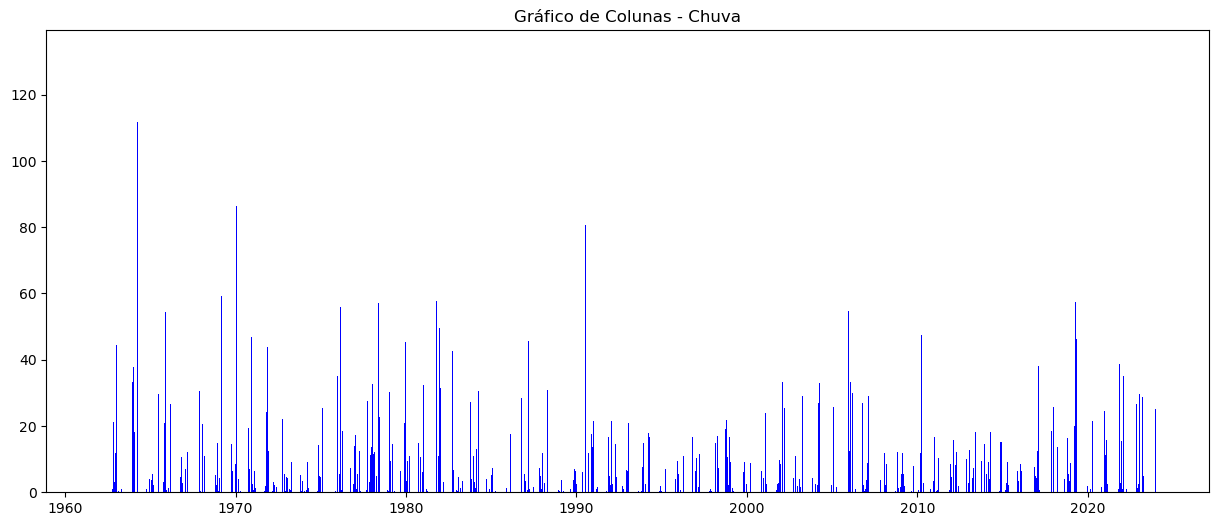

In [40]:
# Gráfico de Colunas com a Coluna "Chuva"
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.bar(df_1547004['Data'], df_1547004['Chuva'],
        color='blue', width=1)
plt.title('Gráfico de Colunas - Chuva')

Text(0.5, 1.0, 'Gráfico de Colunas - Chuva')

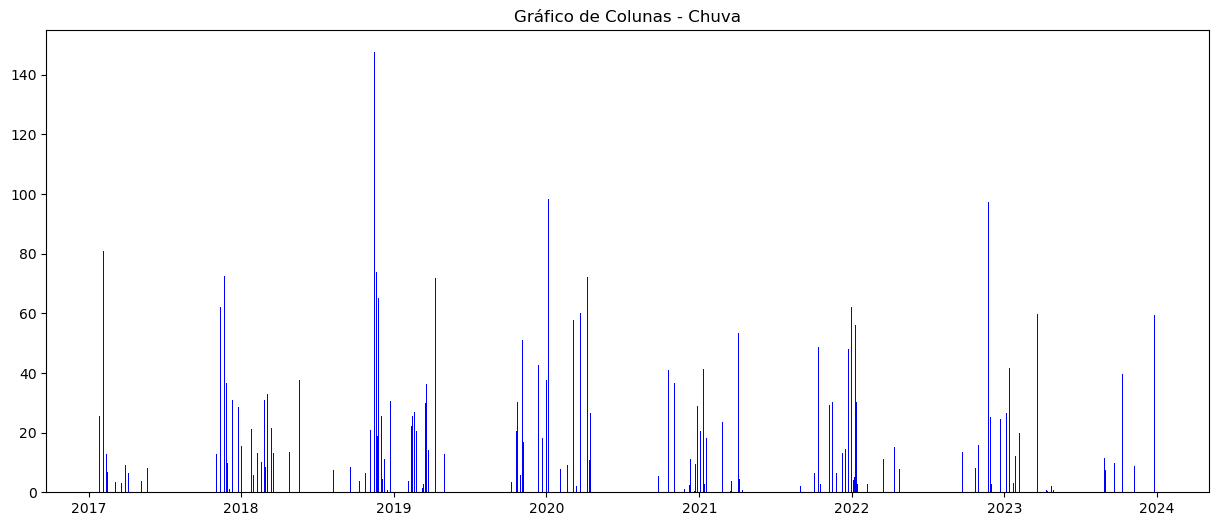

In [41]:
# Gráfico de Colunas com a Coluna "Chuva"
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
plt.bar(df_1548051['Data'], df_1548051['Chuva'],
        color='blue', width=1)
plt.title('Gráfico de Colunas - Chuva')

In [42]:
# Identificar outliers usando o método do desvio interquartil (IQR)
Q1 = df_1547004['Chuva'].quantile(0.25)
Q3 = df_1547004['Chuva'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_1547004[(df_1547004['Chuva'] < limite_inferior) | (df_1547004['Chuva'] > limite_superior)]    

print("Outliers identificados:")
print(outliers)

Outliers identificados:
       cod_estacao  NivelConsistencia       Data      Hora  Chuva
14656      1547004                  1 1962-01-09  00:00:00   33.1
14657      1547004                  1 1962-01-10  00:00:00    6.0
14661      1547004                  1 1962-01-14  00:00:00    6.0
14668      1547004                  1 1962-01-21  00:00:00   10.0
14671      1547004                  1 1962-01-24  00:00:00    6.0
...            ...                ...        ...       ...    ...
37282      1547004                  1 2023-12-21  00:00:00   25.0
37284      1547004                  1 2023-12-23  00:00:00   10.2
37285      1547004                  1 2023-12-24  00:00:00   16.5
37287      1547004                  1 2023-12-26  00:00:00   14.4
37292      1547004                  1 2023-12-31  00:00:00   28.5

[4181 rows x 5 columns]


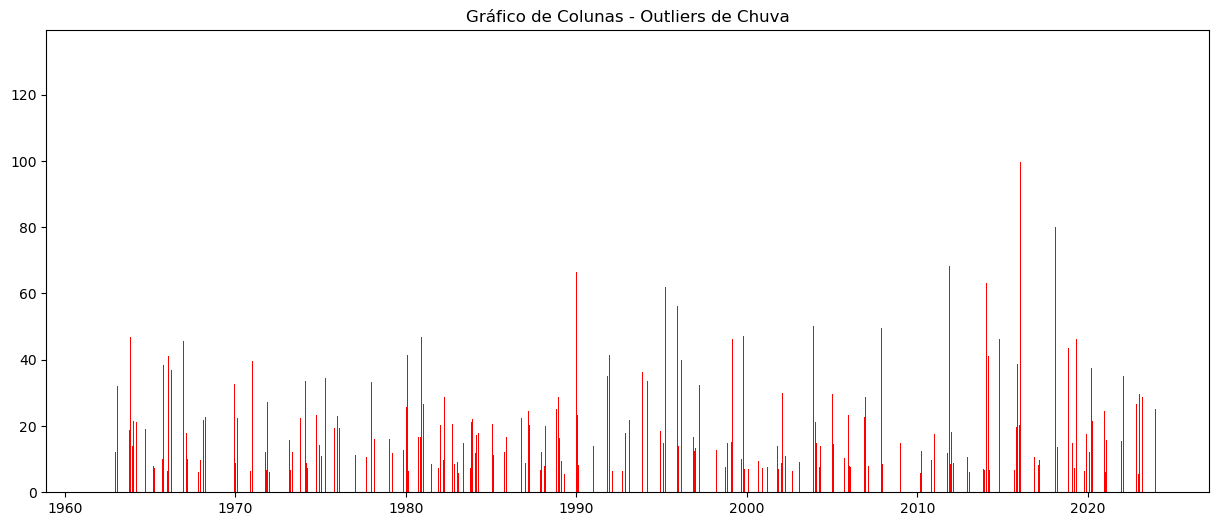

In [43]:
# Gráfico de outliers
plt.figure(figsize=(15, 6))
plt.bar(outliers['Data'], outliers['Chuva'], color='red', width=1)
plt.title('Gráfico de Colunas - Outliers de Chuva') 
plt.show()


In [44]:
# Z-score method
from scipy import stats
z_scores = stats.zscore(df_1547004['Chuva'].dropna())
abs_z_scores = np.abs(z_scores)
outliers_z = df_1547004.loc[df_1547004['Chuva'].dropna().index[abs_z_scores > 3]]
print("Outliers identificados pelo método Z-score:")
print(outliers_z)


Outliers identificados pelo método Z-score:
       cod_estacao  NivelConsistencia       Data      Hora  Chuva
14672      1547004                  1 1962-01-25  00:00:00   71.0
14679      1547004                  1 1962-02-01  00:00:00   40.5
14915      1547004                  1 1962-09-25  00:00:00   39.5
14916      1547004                  1 1962-09-26  00:00:00   45.5
14917      1547004                  1 1962-09-27  00:00:00   39.0
...            ...                ...        ...       ...    ...
36877      1547004                  1 2022-11-11  00:00:00   49.6
36882      1547004                  1 2022-11-16  00:00:00   89.2
36892      1547004                  1 2022-11-26  00:00:00   40.4
36922      1547004                  1 2022-12-26  00:00:00   41.3
37028      1547004                  1 2023-04-11  00:00:00   72.0

[576 rows x 5 columns]


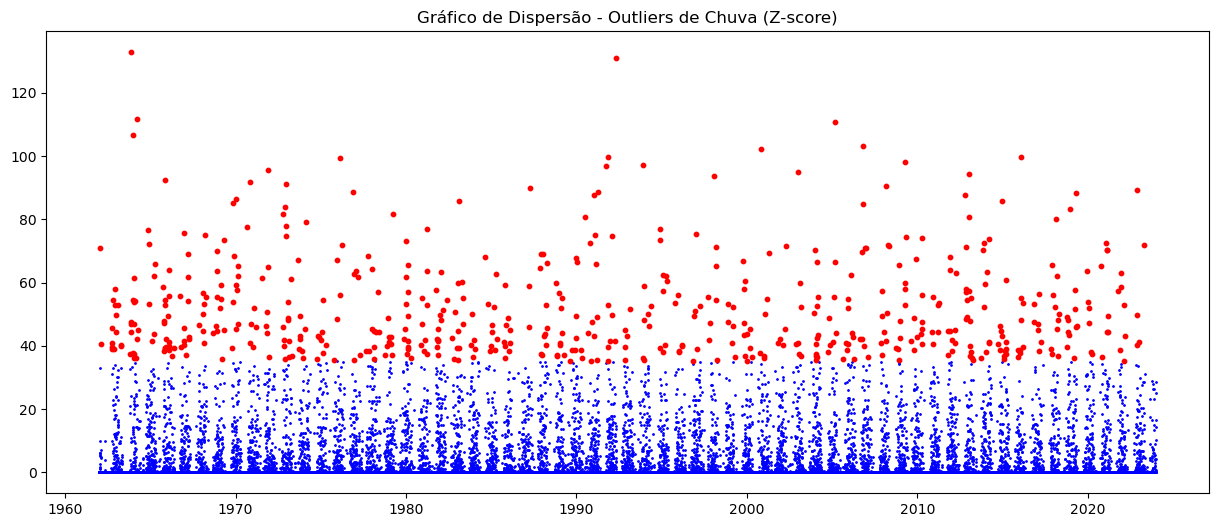

In [45]:
# Criar uma gráfico de dispersão para visualizar os outliers
plt.figure(figsize=(15, 6))
plt.scatter(df_1547004['Data'], df_1547004['Chuva'], color='blue', s=1)
plt.scatter(outliers_z['Data'], outliers_z['Chuva'], color='red', s=10)
plt.title('Gráfico de Dispersão - Outliers de Chuva (Z-score)') 
plt.show()

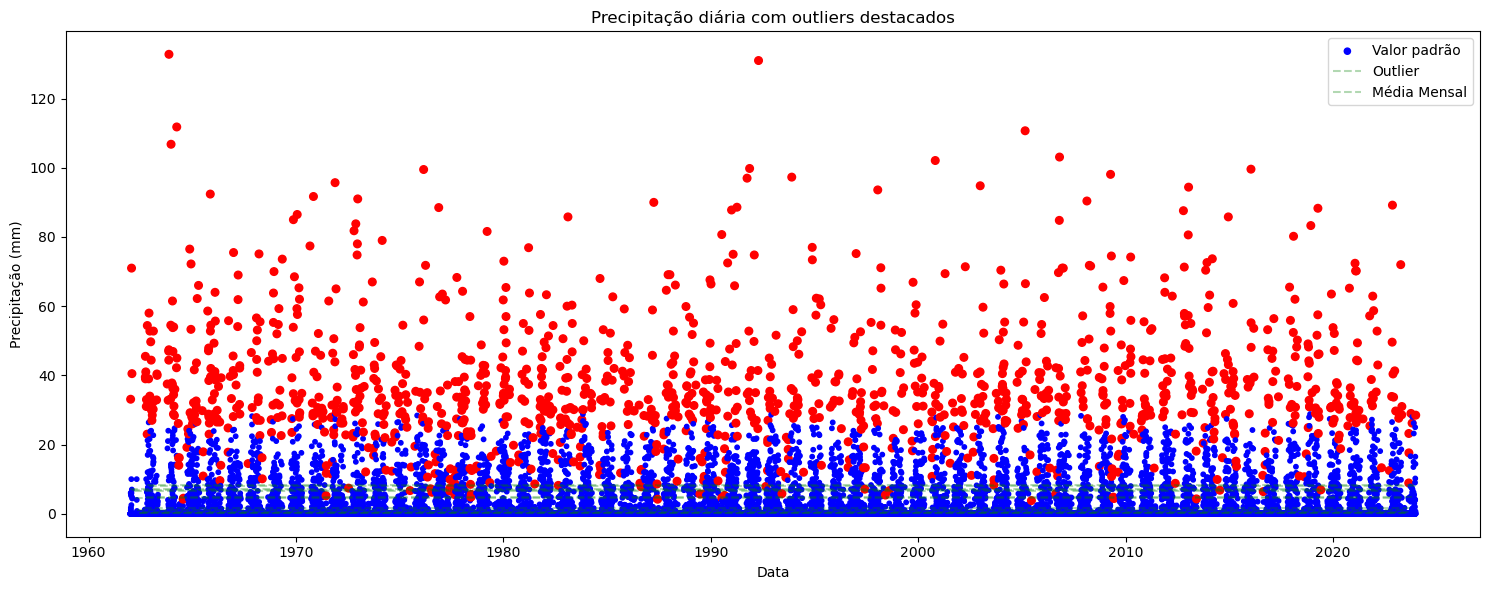

In [46]:
import pandas as pd
import matplotlib.pyplot as plt


df = df_1547004.copy()

# Certifique-se que 'data' é datetime
df['Data'] = pd.to_datetime(df['Data'])
df['mes'] = df['Data'].dt.month

# Adiciona colunas de referência estatística por mês
df['media_mes'] = df.groupby('mes')['Chuva'].transform('mean')
df['std_mes'] = df.groupby('mes')['Chuva'].transform('std')
df['limite_superior'] = df['media_mes'] + 1.5*df['std_mes']

# Identifica outliers (acima do padrão para o mês)
df['outlier'] = df['Chuva'] > df['limite_superior']
    
# --- GRÁFICO ---
plt.figure(figsize=(15, 6))
plt.scatter(df['Data'], df['Chuva'], 
            c=df['outlier'].map({False: 'blue', True: 'red'}), 
            s=df['outlier'].map({False: 10, True: 30}), 
            label='Diária')

# Plota linha da média mensal (um por mês)
for mes in range(1, 13):
    dados_mes = df[df['mes'] == mes]
    plt.hlines(dados_mes['media_mes'].iloc[0], dados_mes['Data'].min(), dados_mes['Data'].max(),
               color='green', linestyle='--', alpha=0.3, label='Média Mensal' if mes==1 else "")

plt.xlabel('Data')
plt.ylabel('Precipitação (mm)')
plt.title('Precipitação diária com outliers destacados')
plt.legend(['Valor padrão', 'Outlier', 'Média Mensal'])
plt.tight_layout()
plt.show()

In [47]:
df

,cod_estacao,NivelConsistencia,Data,Hora,Chuva,mes,media_mes,std_mes,limite_superior,outlier
14648,1547004,1,1962-01-01,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14649,1547004,1,1962-01-02,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14650,1547004,1,1962-01-03,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14651,1547004,1,1962-01-04,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14652,1547004,1,1962-01-05,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
...,...,...,...,...,...,...,...,...,...,...
37288,1547004,1,2023-12-27,00:00:00,0.0,12,7.929917,12.907782,27.291590,False
37289,1547004,1,2023-12-28,00:00:00,0.0,12,7.929917,12.907782,27.291590,False
37290,1547004,1,2023-12-29,00:00:00,0.6,12,7.929917,12.907782,27.291590,False
37291,1547004,1,2023-12-30,00:00:00,0.0,12,7.929917,12.907782,27.291590,False


In [48]:
df

,cod_estacao,NivelConsistencia,Data,Hora,Chuva,mes,media_mes,std_mes,limite_superior,outlier
14648,1547004,1,1962-01-01,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14649,1547004,1,1962-01-02,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14650,1547004,1,1962-01-03,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14651,1547004,1,1962-01-04,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
14652,1547004,1,1962-01-05,00:00:00,0.0,1,7.010510,12.502925,25.764897,False
...,...,...,...,...,...,...,...,...,...,...
37288,1547004,1,2023-12-27,00:00:00,0.0,12,7.929917,12.907782,27.291590,False
37289,1547004,1,2023-12-28,00:00:00,0.0,12,7.929917,12.907782,27.291590,False
37290,1547004,1,2023-12-29,00:00:00,0.6,12,7.929917,12.907782,27.291590,False
37291,1547004,1,2023-12-30,00:00:00,0.0,12,7.929917,12.907782,27.291590,False


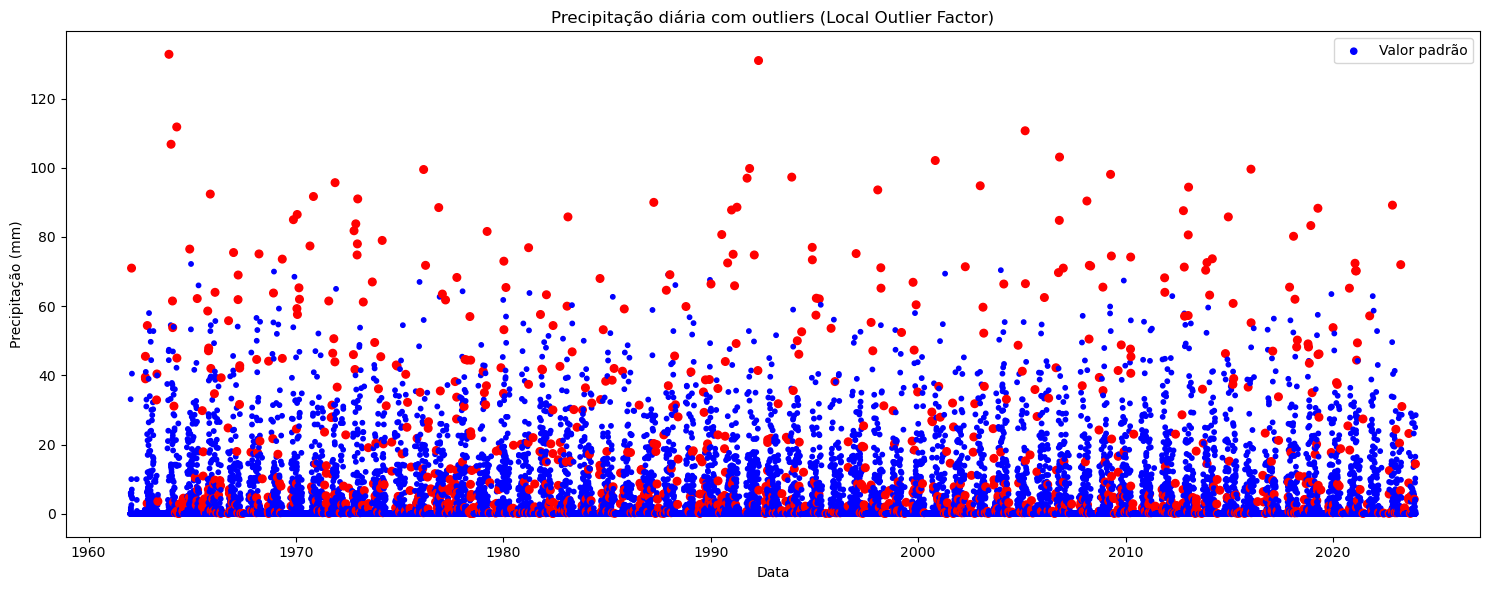

In [ ]:
from pyod.models.lof import LOF

df = df_1547004.copy()

# Certifique-se que 'data' é datetime
df['Data'] = pd.to_datetime(df['Data'])
df['mes'] = df['Data'].dt.month

# Para cada mês, detecta outliers usando LOF
outlier_flags = np.zeros(df.shape[0], dtype=bool)

for mes in range(1, 13):
    idx = df['mes'] == mes
    # Remove NaN values for LOF input
    idx_valid = idx & df['Chuva'].notna()
    dados_mes = df.loc[idx_valid, 'Chuva'].values.reshape(-1, 1)
    
    if len(dados_mes) == 0:
        continue

    # LOF
    # lof = LOF(contamination=0.05, n_neighbors=20)
    lof = LOF(contamination=0.05)
    lof.fit(dados_mes)
    preds = lof.labels_  # 1 = outlier, 0 = inlier

    # Marca outliers apenas nos índices válidos
    outlier_flags[idx_valid] = preds.astype(bool)

df['outlier'] = outlier_flags

# --- GRÁFICO ---
plt.figure(figsize=(15, 6))
plt.scatter(df['Data'], df['Chuva'], 
            c=df['outlier'].map({False: 'blue', True: 'red'}),
            s=df['outlier'].map({False: 10, True: 30}),
            label='Diária')

plt.xlabel('Data')
plt.ylabel('Precipitação (mm)')
plt.title('Precipitação diária com outliers (Local Outlier Factor)')
plt.legend(['Valor padrão', 'Outlier'])
plt.tight_layout()
plt.show()

In [50]:
df

,cod_estacao,NivelConsistencia,Data,Hora,Chuva,mes,outlier
14648,1547004,1,1962-01-01,00:00:00,0.0,1,False
14649,1547004,1,1962-01-02,00:00:00,0.0,1,False
14650,1547004,1,1962-01-03,00:00:00,0.0,1,False
14651,1547004,1,1962-01-04,00:00:00,0.0,1,False
14652,1547004,1,1962-01-05,00:00:00,0.0,1,False
...,...,...,...,...,...,...,...
37288,1547004,1,2023-12-27,00:00:00,0.0,12,False
37289,1547004,1,2023-12-28,00:00:00,0.0,12,False
37290,1547004,1,2023-12-29,00:00:00,0.6,12,False
37291,1547004,1,2023-12-30,00:00:00,0.0,12,False


In [51]:
# Contar quantos outliers foram detectados
num_outliers = df['outlier'].sum()
print(f"Número de outliers detectados: {num_outliers}")

Número de outliers detectados: 1065


In [52]:
# Se é outlier, substitui por NaN
df_p = df.copy()
df_p.loc[df_p['outlier'] == True, 'Chuva'] = np.nan

In [53]:
df_p = df_p[['cod_estacao', 'NivelConsistencia', 'Data', 'Hora', 'Chuva']]

In [ ]:
df_p

In [54]:
df_p.to_csv('df_1547004_outliers_lof.csv', index=False)

In [55]:
df_p

,cod_estacao,NivelConsistencia,Data,Hora,Chuva
14648,1547004,1,1962-01-01,00:00:00,0.0
14649,1547004,1,1962-01-02,00:00:00,0.0
14650,1547004,1,1962-01-03,00:00:00,0.0
14651,1547004,1,1962-01-04,00:00:00,0.0
14652,1547004,1,1962-01-05,00:00:00,0.0
...,...,...,...,...,...
37288,1547004,1,2023-12-27,00:00:00,0.0
37289,1547004,1,2023-12-28,00:00:00,0.0
37290,1547004,1,2023-12-29,00:00:00,0.6
37291,1547004,1,2023-12-30,00:00:00,0.0


In [56]:
# Ler dado de vazão 
arquivo_flu = os.path.join(os.getcwd(), "FLU_Series_ANA.txt")
df_60477600 = ler_csv(arquivo_flu, 60477600, '1971-01-01', '2023-12-31')

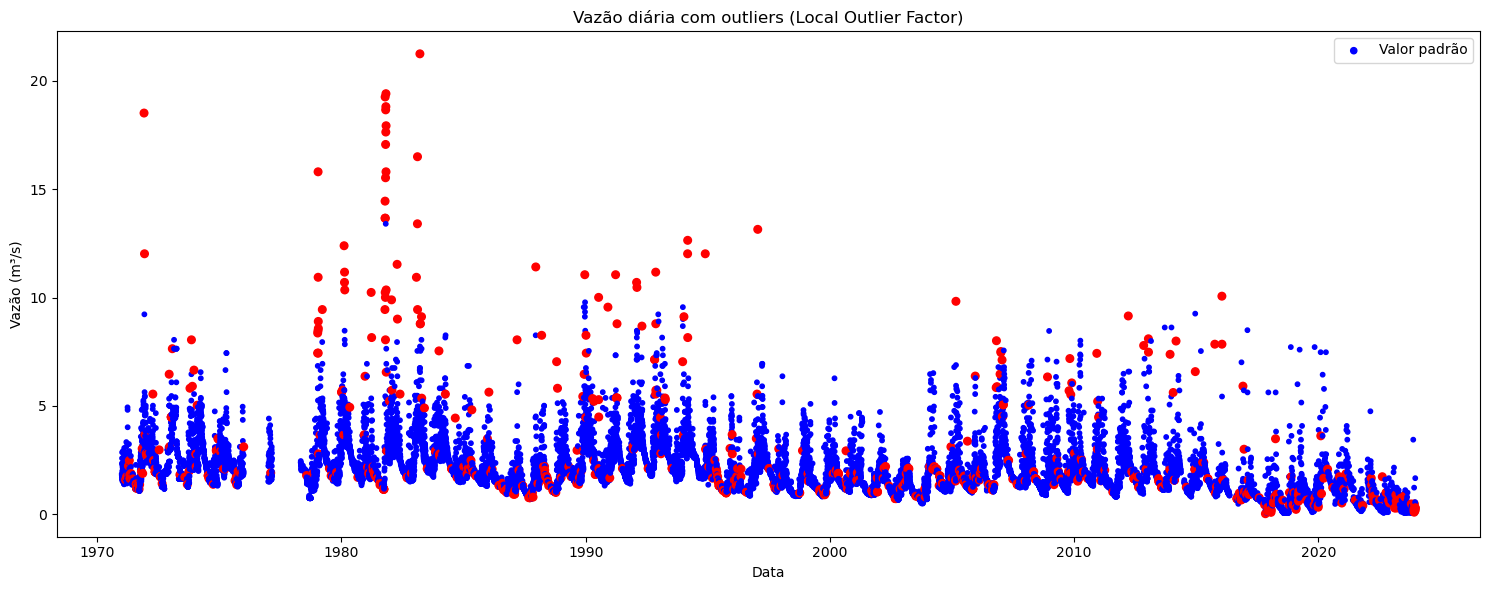

In [57]:
df = df_60477600.copy()

# Certifique-se que 'data' é datetime
df['Data'] = pd.to_datetime(df['Data'])
df['mes'] = df['Data'].dt.month

# Para cada mês, detecta outliers usando LOF
outlier_flags = np.zeros(df.shape[0], dtype=bool)

for mes in range(1, 13):
    idx = df['mes'] == mes
    # Remove NaN values for LOF input
    idx_valid = idx & df['Vazao'].notna()
    dados_mes = df.loc[idx_valid, 'Vazao'].values.reshape(-1, 1)
    
    if len(dados_mes) == 0:
        continue

    # LOF
    # lof = LOF(contamination=0.05, n_neighbors=20)
    lof = LOF(contamination=0.05)
    lof.fit(dados_mes)
    preds = lof.labels_  # 1 = outlier, 0 = inlier

    # Marca outliers apenas nos índices válidos
    outlier_flags[idx_valid] = preds.astype(bool)

df['outlier'] = outlier_flags

# --- GRÁFICO ---
plt.figure(figsize=(15, 6))
plt.scatter(df['Data'], df['Vazao'], 
            c=df['outlier'].map({False: 'blue', True: 'red'}),
            s=df['outlier'].map({False: 10, True: 30}),
            label='Diária')

plt.xlabel('Data')
plt.ylabel('Vazão (m³/s)')
plt.title('Vazão diária com outliers (Local Outlier Factor)')
plt.legend(['Valor padrão', 'Outlier'])
plt.tight_layout()
plt.show()

In [58]:
df.dtypes

cod_estacao                   int64
NivelConsistencia             int64
Data                 datetime64[ns]
Hora                         object
Vazao                       float64
mes                           int32
outlier                        bool
dtype: object

In [59]:
df_v = df.copy()
df_v.loc[df_v['outlier'] == True, 'Vazao'] = np.nan

del df

In [ ]:
df_v

In [ ]:
df_v = df_v[['cod_estacao', 'NivelConsistencia', 'Data', 'Hora', 'Vazao']]

In [61]:
df_v.to_csv('df_60477600_outliers_lof.csv', index=False)

In [62]:
# Mesclar os dados de chuva e vazão pela coluna 'Data'
df_merged = pd.merge(df_p, df_v[['Data', 'Vazao']], on='Data', how='inner')

# Remover linhas com valores NaN em 'Chuva' ou 'Vazao'
df_merged = df_merged.dropna(subset=['Chuva', 'Vazao'])

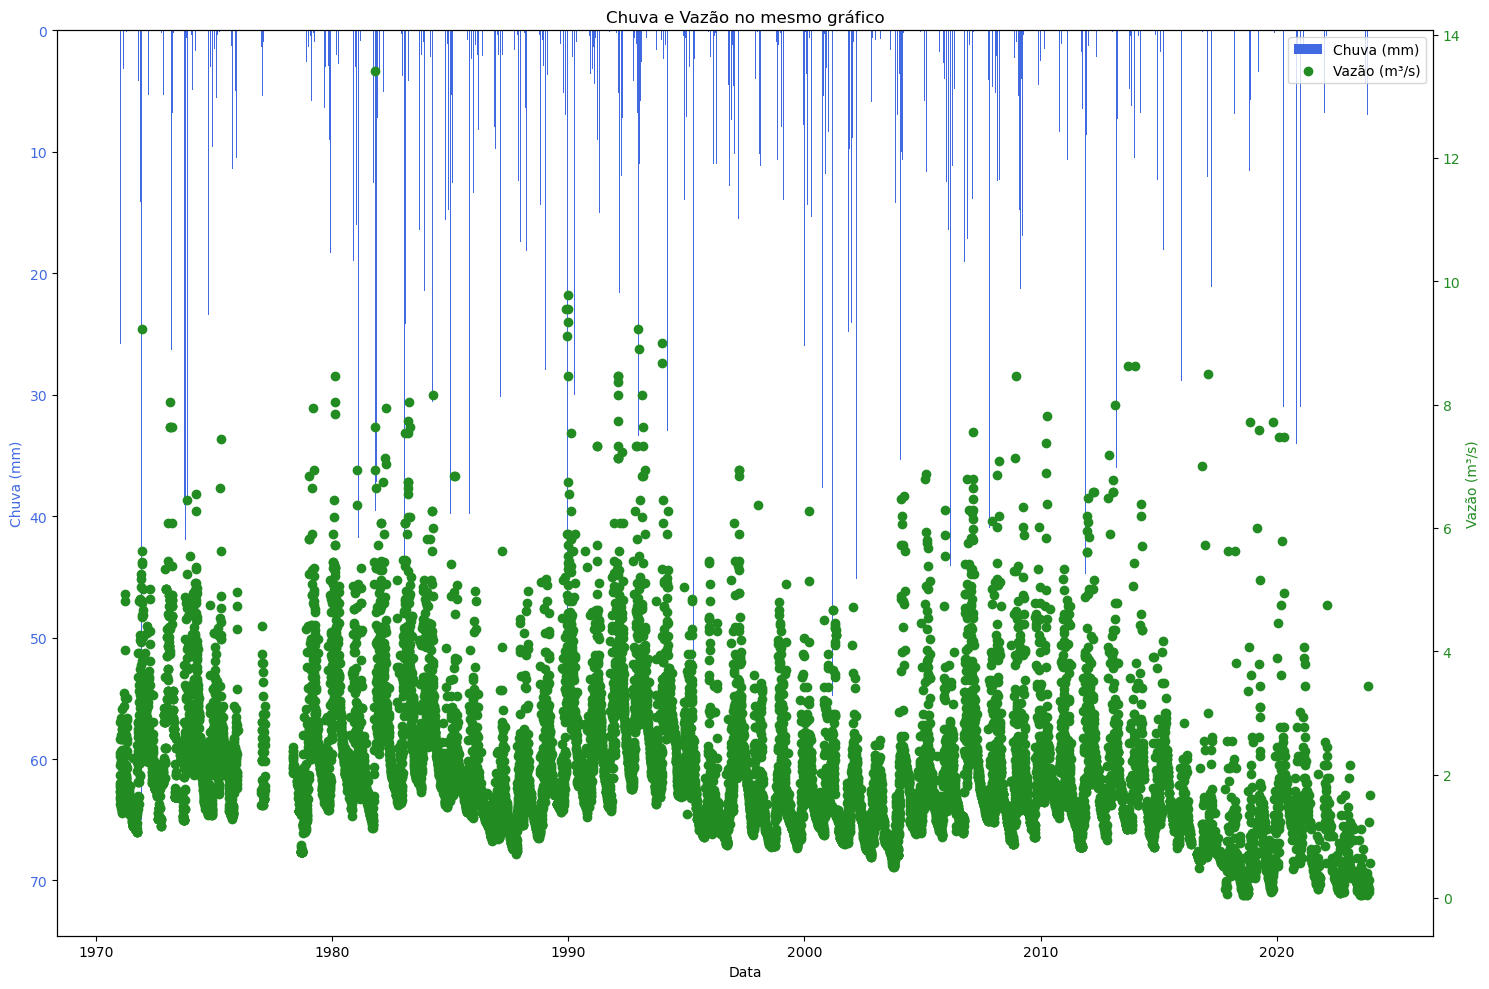

In [63]:
fig, ax1 = plt.subplots(figsize=(15,10))

ax1.bar(df_merged['Data'], df_merged['Chuva'], color='royalblue', width=0.8, label='Chuva (mm)')
ax1.set_ylabel('Chuva (mm)', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xlabel('Data')

# Inverte o eixo Y para mostrar valores positivos
ax1.invert_yaxis()

ax2 = ax1.twinx()
ax2.scatter(df_merged['Data'], df_merged['Vazao'], color='forestgreen', label='Vazão (m³/s)')
ax2.set_ylabel('Vazão (m³/s)', color='forestgreen')
ax2.tick_params(axis='y', labelcolor='forestgreen')

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.title('Chuva e Vazão no mesmo gráfico')
plt.tight_layout()
plt.show()

In [75]:
df_n90 = df_1547004[(df_1547004['Data'] >= '1979-07-01') & (df_1547004['Data'] <= '1979-07-31')] # N=90
df_n24 = df_1547004[(df_1547004['Data'] >= '1972-12-01') & (df_1547004['Data'] <= '1972-12-31')] # N=24

dfp_n24 = df_p[(df_p['Data'] >= '1972-12-01') & (df_p['Data'] <= '1972-12-31')] # N=24
dfp_n90 = df_p[(df_p['Data'] >= '1979-07-01') & (df_p['Data'] <= '1979-07-31')] # N=90


# Fazer merge horizontal criando colunas para cada período
df_merge_ns = df_n90[['Data', 'Chuva']].rename(columns={'Chuva': 'Chuva_n90_original'})
df_merge_ns = df_merge_ns.merge(df_n24[['Data', 'Chuva']].rename(columns={'Chuva': 'Chuva_n24_original'}), on='Data', how='outer')
df_merge_ns = df_merge_ns.merge(dfp_n24[['Data', 'Chuva']].rename(columns={'Chuva': 'Chuva_n24_processado'}), on='Data', how='outer')
df_merge_ns = df_merge_ns.merge(dfp_n90[['Data', 'Chuva']].rename(columns={'Chuva': 'Chuva_n90_processado'}), on='Data', how='outer')

In [76]:
df_merge_ns

,Data,Chuva_n90_original,Chuva_n24_original,Chuva_n24_processado,Chuva_n90_processado
0,1972-12-01,NaN,0.0,0.0,NaN
1,1972-12-02,NaN,0.0,0.0,NaN
2,1972-12-03,NaN,0.0,0.0,NaN
3,1972-12-04,NaN,0.0,0.0,NaN
4,1972-12-05,NaN,0.0,0.0,NaN
...,...,...,...,...,...
57,1979-07-27,0.0,NaN,NaN,0.0
58,1979-07-28,0.0,NaN,NaN,0.0
59,1979-07-29,0.0,NaN,NaN,0.0
60,1979-07-30,0.0,NaN,NaN,0.0
